# VGGT 3D Reconstruction Walkthrough

This notebook recreates the 3D reconstruction steps used by `demo_viser.py` on the capture stored at `./dataset/astera_office_2/images/`. Each section exposes an intermediate prediction so you can inspect how VGGT builds cameras, depth, and point clouds.

## 0. Imports and runtime setup
Make sure the VGGT environment is activated before executing the cells.

In [6]:
import sys
sys.path.insert(0, 'G:/GithubProject/egocentric_control/vggt-loc/vggt')

In [7]:
%matplotlib inline

import os
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri
from vggt.utils.geometry import unproject_depth_map_to_point_map, closed_form_inverse_se3


c:\Users\lycaz\.conda\envs\vggt_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
IMAGE_FOLDER = Path("astera_office_2/images")
assert IMAGE_FOLDER.exists(), f"Image folder not found: {IMAGE_FOLDER}"

image_paths = sorted(
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
)

MAX_IMAGES = None  # set to an integer to limit the sequence if memory becomes an issue
if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f"Found {len(image_paths)} images")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8 else torch.float16
print(f"Using device: {device}, autocast dtype: {dtype}")


Found 41 images
Using device: cuda, autocast dtype: torch.bfloat16


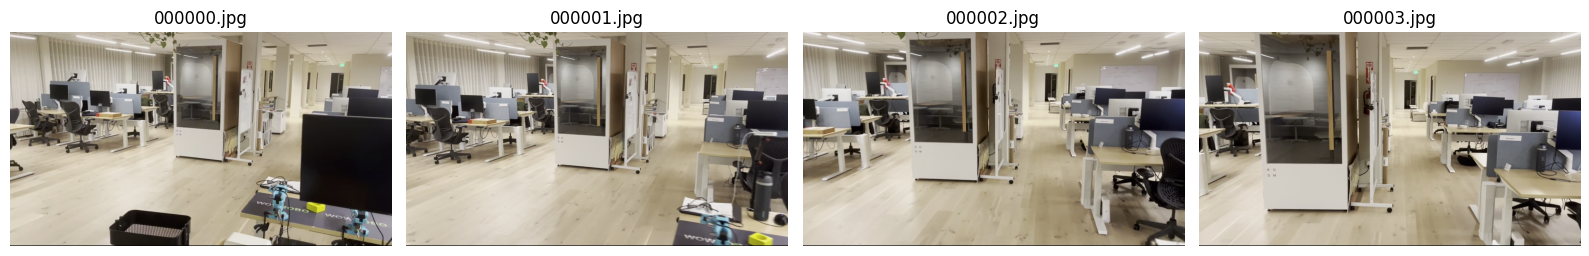

In [33]:
num_preview = min(4, len(image_paths))
if num_preview > 0:
    fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
    if num_preview == 1:
        axes = [axes]
    for ax, path in zip(axes, image_paths[:num_preview]):
        ax.imshow(Image.open(path))
        ax.set_title(path.name)
        ax.axis("off")
    plt.tight_layout()
else:
    raise RuntimeError("No images found for reconstruction.")


## 1. Load and preprocess images
This step mirrors `load_and_preprocess_images` from the demo script.


In [34]:
images_tensor = load_and_preprocess_images([str(p) for p in image_paths])
print(f"Preprocessed tensor shape: {images_tensor.shape}")
images_tensor = images_tensor.to(device)

Preprocessed tensor shape: torch.Size([41, 3, 294, 518])


## 2. Instantiate VGGT and load weights
Weights are fetched from the public Hugging Face checkpoint the first time you run this cell.

In [35]:
# model = VGGT()
# state_dict = torch.hub.load_state_dict_from_url("https://huggingface.co/facebook/VGGT-1B/resolve/main/model.pt", progress=True, map_location="cpu")
# model.load_state_dict(state_dict)
# model = model.to(device)
# model.eval()
# print("Model ready for inference.")
model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)
model.eval();


c:\Users\lycaz\.conda\envs\vggt_py312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lycaz\.cache\huggingface\hub\models--facebook--VGGT-1B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP down

## 3. Aggregate image tokens
VGGT first converts the image sequence into transformer tokens via the aggregator module.

In [36]:
with torch.no_grad():
    batched_images = images_tensor.unsqueeze(0)  # add batch dimension
    autocast_ctx = torch.cuda.amp.autocast(dtype=dtype) if device.type == "cuda" else nullcontext()
    with autocast_ctx:
        aggregated_tokens_list, patch_start_idx = model.aggregator(batched_images)

print(f"Number of refinement iterations: {len(aggregated_tokens_list)}")
print("Token shapes:", [t.shape for t in aggregated_tokens_list])
print(f"Patch start index: {patch_start_idx}")


G:\GithubProject/egocentric_control/vggt-loc/vggt\vggt\layers\attention.py:61: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  x = F.scaled_dot_product_attention(q, k, v, dropout_p=self.attn_drop.p if self.training else 0.0)


Number of refinement iterations: 24
Token shapes: [torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048])]
Patch start index: 5


## 4. Predict cameras, depth, points, and tracks
Using the aggregated tokens we replicate the per-head calls from the demo script.

In [37]:
with torch.no_grad():
    # Camera poses
    pose_enc_list = model.camera_head(aggregated_tokens_list)
    pose_enc = pose_enc_list[-1]
    extrinsic, intrinsic = pose_encoding_to_extri_intri(pose_enc, batched_images.shape[-2:])

    # Dense depth and point predictions
    depth_map, depth_conf = model.depth_head(aggregated_tokens_list, batched_images, patch_start_idx)
    point_map, point_conf = model.point_head(aggregated_tokens_list, batched_images, patch_start_idx)

    # Example point tracking query
    query_points = torch.tensor([[100.0, 200.0], [60.72, 259.94]], device=device)
    track_list, vis_score, conf_score = model.track_head(
        aggregated_tokens_list, batched_images, patch_start_idx, query_points=query_points[None]
    )

print(f"Pose encoding shape: {pose_enc.shape}")
print(f"Extrinsic shape: {extrinsic.shape}, Intrinsic shape: {intrinsic.shape}")
print(f"Depth map shape: {depth_map.shape}, depth confidence shape: {depth_conf.shape}")
print(f"Point map shape: {point_map.shape}, point confidence shape: {point_conf.shape}")
print(f"Track list length: {len(track_list)}, track tensor shape: {track_list[-1].shape}")


Pose encoding shape: torch.Size([1, 41, 9])
Extrinsic shape: torch.Size([1, 41, 3, 4]), Intrinsic shape: torch.Size([1, 41, 3, 3])
Depth map shape: torch.Size([1, 41, 294, 518, 1]), depth confidence shape: torch.Size([1, 41, 294, 518])
Point map shape: torch.Size([1, 41, 294, 518, 3]), point confidence shape: torch.Size([1, 41, 294, 518])
Track list length: 4, track tensor shape: torch.Size([1, 41, 2, 2])


## 5. Convert depth to 3D points via camera geometry
Unprojecting the depth maps often yields cleaner 3D geometry than the point-map head.

In [38]:
point_map_by_unprojection = unproject_depth_map_to_point_map(
    depth_map.squeeze(0), extrinsic.squeeze(0), intrinsic.squeeze(0)
)
print(f"Unprojected point map shape: {point_map_by_unprojection.shape}")


Unprojected point map shape: (41, 294, 518, 3)


## 6. Visualize intermediate predictions

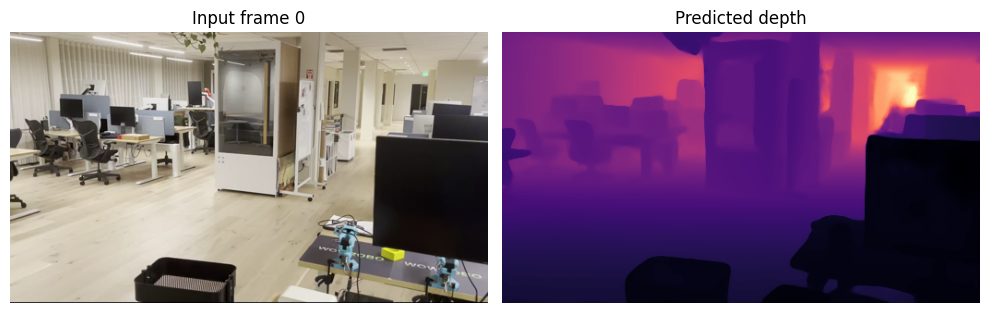

In [39]:
frame_idx = 0  # change to visualize a different frame

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(images_tensor[frame_idx].detach().cpu().permute(1, 2, 0))
axs[0].set_title(f"Input frame {frame_idx}")
axs[0].axis("off")

depth_vis = depth_map[0, frame_idx].detach().cpu().squeeze().numpy()
axs[1].imshow(depth_vis, cmap="magma")
axs[1].set_title("Predicted depth")
axs[1].axis("off")
plt.tight_layout()


In [41]:
import open3d as o3d

sample_frame = 1
points = point_map_by_unprojection[sample_frame].reshape(-1, 3)
colors = images_tensor[sample_frame].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize
print(f"Visualizing {len(pcd.points)} points")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="3D Point Cloud (World Coordinates)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Visualizing 152292 points


In [42]:
import open3d as o3d

# Combine all frames into one point cloud
all_points = []
all_colors = []

for frame_idx in range(len(images_tensor)):
    points = point_map_by_unprojection[frame_idx].reshape(-1, 3)
    colors = images_tensor[frame_idx].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()
    all_points.append(points)
    all_colors.append(colors)

all_points = np.vstack(all_points)
all_colors = np.vstack(all_colors)

# Create and visualize combined point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_points)
pcd.colors = o3d.utility.Vector3dVector(all_colors)

print(f"Visualizing {len(pcd.points)} points from {len(images_tensor)} frames")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="Full Scene Reconstruction (All Frames)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Visualizing 6243972 points from 41 frames


In [43]:
# Combine all frames with confidence filtering (matching demo_viser.py behavior)
all_points = []
all_colors = []
all_conf = []

for frame_idx in range(len(images_tensor)):
    points = point_map_by_unprojection[frame_idx].reshape(-1, 3)
    colors = images_tensor[frame_idx].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()
    conf = depth_conf[0, frame_idx].detach().cpu().numpy().reshape(-1)
    
    all_points.append(points)
    all_colors.append(colors)
    all_conf.append(conf)

# Flatten all frames
points_flat = np.vstack(all_points)
colors_flat = np.vstack(all_colors)
conf_flat = np.concatenate(all_conf)

# Filter by confidence (matching demo_viser.py logic)
percentile = 25.0  # Default --conf_threshold, adjust to remove more/less noise
cutoff = np.percentile(conf_flat, percentile)
valid = (conf_flat >= cutoff) & (conf_flat > 1e-5)

print(f"Confidence cutoff at {percentile}th percentile: {cutoff:.6f}")
print(f"Keeping {valid.sum():,} / {len(valid):,} points ({100 * valid.sum() / len(valid):.1f}%)")

# Filter points and colors
points_filtered = points_flat[valid]
colors_filtered = colors_flat[valid]

# Optional: center the point cloud like demo_viser.py
points_centered = points_filtered - points_filtered.mean(axis=0)

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_centered)  # Use points_filtered if you don't want centering
pcd.colors = o3d.utility.Vector3dVector(colors_filtered)

# Optional: statistical outlier removal for even cleaner results
pcd, outlier_mask = pcd.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.0)
print(f"After outlier removal: {len(pcd.points):,} points")

# Visualize
print(f"Visualizing filtered point cloud from {len(images_tensor)} frames")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="Filtered Scene Reconstruction (All Frames)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Confidence cutoff at 25.0th percentile: 1.000820
Keeping 4,682,990 / 6,243,972 points (75.0%)
After outlier removal: 4,150,105 points
Visualizing filtered point cloud from 41 frames


## 7. Visualize camera poses
Overlay the estimated camera frames on an Open3D rendering of the filtered point cloud (OpenCV convention: x→red, y→green, z→blue).

In [ ]:
import open3d as o3d
from vggt.utils.geometry import closed_form_inverse_se3

# Confidence-filtered point cloud (match demo_viser percentile filtering)
conf_flat = depth_conf[0].detach().cpu().numpy().reshape(-1)
points_flat = point_map_by_unprojection.reshape(-1, 3)
colors_flat = images_tensor.detach().cpu().permute(0, 2, 3, 1).numpy().reshape(-1, 3)

percentile = 25.0  # drop the lowest-confidence pixels
cutoff = np.percentile(conf_flat, percentile)
valid = (conf_flat >= cutoff) & (conf_flat > 1e-5)

pcd_filtered = o3d.geometry.PointCloud()
pcd_filtered.points = o3d.utility.Vector3dVector(points_flat[valid])
pcd_filtered.colors = o3d.utility.Vector3dVector(colors_flat[valid])

# Rotate scene so that Y becomes up (180° about X to preserve handedness)
world_fix = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, -1.0, 0.0, 0.0],
        [0.0, 0.0, -1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ],
    dtype=np.float32,
)

pcd_filtered.transform(world_fix)

# Build camera frames in world coordinates
extrinsic_batch = extrinsic.squeeze(0).detach()
S = extrinsic_batch.shape[0]
extrinsic_h = torch.zeros((S, 4, 4), dtype=extrinsic_batch.dtype, device=extrinsic_batch.device)
extrinsic_h[:, :3, :4] = extrinsic_batch
extrinsic_h[:, 3, 3] = 1.0

cam_to_world = closed_form_inverse_se3(extrinsic_h).cpu().numpy()

frame_scale = 0.05  # adjust to match your scene scale
camera_frames = []
for idx, T in enumerate(cam_to_world):
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_scale)
    frame.transform(world_fix @ T)
    camera_frames.append(frame)

print(f"Filtered points: {len(pcd_filtered.points)} | Cameras: {len(camera_frames)}")

o3d.visualization.draw_geometries(
    [pcd_filtered, *camera_frames],
    window_name="Point cloud with camera poses",
    width=1024,
    height=768,
    left=100,
    top=100,
)


Filtered points: 4682990 | Cameras: 41


In [48]:
import numpy as np
import torch
import open3d as o3d
from vggt.utils.geometry import closed_form_inverse_se3

# --- Inputs assumed to exist from your pipeline ---
# depth_conf: (1, H, W) torch.Tensor
# point_map_by_unprojection: (H*W, 3) or (H, W, 3)
# images_tensor: (B, 3, H, W) torch.Tensor in [0,1]
# extrinsic: (1, S, 3, 4) torch.Tensor
# -------------------------------------------------------------------

# Confidence-filtered point cloud
conf_flat = depth_conf[0].detach().cpu().numpy().reshape(-1)
points_flat = point_map_by_unprojection.reshape(-1, 3)
colors_flat = images_tensor.detach().cpu().permute(0, 2, 3, 1).numpy().reshape(-1, 3)

percentile = 25.0  # drop the lowest-confidence pixels
cutoff = np.percentile(conf_flat, percentile)
valid = (conf_flat >= cutoff) & (conf_flat > 1e-5)

pcd_filtered = o3d.geometry.PointCloud()
pcd_filtered.points = o3d.utility.Vector3dVector(points_flat[valid])
pcd_filtered.colors = o3d.utility.Vector3dVector(colors_flat[valid])

# Rotate scene so that Y becomes up (180° about X to preserve handedness)
world_fix = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, -1.0, 0.0, 0.0],
        [0.0, 0.0, -1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ],
    dtype=np.float32,
)
pcd_filtered.transform(world_fix)

# Build camera frames in world coordinates
extrinsic_batch = extrinsic.squeeze(0).detach()  # (S, 3, 4)
S = extrinsic_batch.shape[0]
extrinsic_h = torch.zeros((S, 4, 4), dtype=extrinsic_batch.dtype, device=extrinsic_batch.device)
extrinsic_h[:, :3, :4] = extrinsic_batch
extrinsic_h[:, 3, 3] = 1.0

# If your 'extrinsic' is world->cam, invert to cam->world
cam_to_world = closed_form_inverse_se3(extrinsic_h).cpu().numpy()

frame_scale = 0.05  # adjust to match your scene scale
camera_frames = []
for T in cam_to_world:
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_scale)
    frame.transform(world_fix @ T)
    camera_frames.append(frame)

# ---------------------- Single reference surface: y = 0 plane ----------------------
# Size the plane to the point cloud extents so it looks "complete" in view.
aabb_min = pcd_filtered.get_min_bound()
aabb_max = pcd_filtered.get_max_bound()
extent = aabb_max - aabb_min
scene_scale = max(1e-6, np.linalg.norm(extent))
pad = 0.1 * scene_scale   # extra margin beyond the cloud
eps = 1e-3 * scene_scale  # very thin thickness (appears as a plane)

x_min, y_min, z_min = aabb_min
x_max, y_max, z_max = aabb_max
x_center = 0.5 * (x_min + x_max)
z_center = 0.5 * (z_min + z_max)

# Plane y = 0 (XZ plane; "ground")
w_xz = (x_max - x_min) + pad
d_xz = (z_max - z_min) + pad
plane_y0 = o3d.geometry.TriangleMesh.create_box(width=w_xz, height=eps, depth=d_xz)
plane_y0.translate([x_center - w_xz / 2.0, -eps / 2.0, z_center - d_xz / 2.0])
plane_y0.paint_uniform_color([0.85, 0.85, 0.85])  # light gray
plane_y0.compute_vertex_normals()
# ------------------------------------------------------------------------------

print(f"Filtered points: {len(pcd_filtered.points)} | Cameras: {len(camera_frames)}")

o3d.visualization.draw_geometries(
    [pcd_filtered, plane_y0, *camera_frames],
    window_name="Point cloud with camera poses and y=0 surface",
    width=1024,
    height=768,
    left=100,
    top=100,
)


Filtered points: 4682990 | Cameras: 41


### 7.1 Ground finding 

In [59]:
import numpy as np
import open3d as o3d
import time
from typing import List, Tuple, Dict, Any

def find_ground_and_camera_planes(
    pcd_filtered: o3d.geometry.PointCloud,
    camera_frames: List[o3d.geometry.TriangleMesh],
    *,
    show_viewer: bool = False,
    ground_color: Tuple[float, float, float] = (0.8, 0.4, 0.2),
    camera_plane_color: Tuple[float, float, float] = (0.0, 0.8, 0.3),
    ransac_dist_thresh: float = 0.01,
    ransac_max_iters: int = 1500,
    window_name: str = "Point cloud with ground & camera planes",
    width: int = 1280,
    height: int = 720
) -> Dict[str, Any]:
    """
    Finds BOTH planes:
      - Ground plane: RANSAC on point cloud
      - Camera plane: least-squares fit on camera frame centers
    Prints timing for each, and (optionally) visualizes.
    Returns ONLY the plane definitions: normal and d (n·x + d = 0).
    """

    assert isinstance(pcd_filtered, o3d.geometry.PointCloud), "pcd_filtered must be an Open3D PointCloud"
    if len(pcd_filtered.points) == 0:
        raise ValueError("pcd_filtered has no points.")
    if camera_frames is None or len(camera_frames) < 3:
        raise ValueError("Need at least 3 camera frames to fit the camera plane.")

    # ---------- helpers ----------
    def ransac_plane(points: np.ndarray, dist_thresh: float, max_iters: int):
        best_inliers = None
        best_normal = None
        best_d = None
        best_count = 0
        n = points.shape[0]
        if n < 3:
            return None, None, None

        rng = np.random.default_rng()
        for _ in range(max_iters):
            idx = rng.choice(n, 3, replace=False)
            p1, p2, p3 = points[idx]
            v1 = p2 - p1
            v2 = p3 - p1
            normal = np.cross(v1, v2)
            norm = np.linalg.norm(normal)
            if norm < 1e-9:
                continue
            normal = normal / norm
            d = -np.dot(normal, p1)
            distances = np.abs(points @ normal + d)
            inliers = distances < dist_thresh
            count = int(inliers.sum())
            if count > best_count:
                best_count = count
                best_inliers = inliers
                best_normal = normal
                best_d = d

        # refine with least squares on inliers
        if best_inliers is not None and best_count >= 3:
            inlier_pts = points[best_inliers]
            ctr = inlier_pts.mean(axis=0)
            centered = inlier_pts - ctr
            _, _, vh = np.linalg.svd(centered, full_matrices=False)
            normal = vh[-1]
            normal = normal / np.linalg.norm(normal)
            d = -np.dot(normal, ctr)
            return normal, d, best_inliers
        return None, None, None

    def plane_local_coords(points3d: np.ndarray, normal: np.ndarray, d: float):
        # Project to plane and build orthonormal basis (u,v) on the plane
        distances = points3d @ normal + d
        proj = points3d - np.outer(distances, normal)

        arbitrary = np.array([1.0, 0.0, 0.0]) if abs(normal[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        u = arbitrary - (arbitrary @ normal) * normal
        u /= np.linalg.norm(u)
        v = np.cross(normal, u)
        v /= np.linalg.norm(v)

        origin = proj.mean(axis=0)
        rel = proj - origin
        coords_2d = np.stack([rel @ u, rel @ v], axis=1)
        return coords_2d, u, v, origin

    def rect_mesh_from_plane_bbox(normal: np.ndarray, d: float, points3d: np.ndarray,
                                  color=(0.8, 0.4, 0.2)):
        coords_2d, u, v, origin = plane_local_coords(points3d, normal, d)
        umin, umax = coords_2d[:, 0].min(), coords_2d[:, 0].max()
        vmin, vmax = coords_2d[:, 1].min(), coords_2d[:, 1].max()
        corners_2d = np.array([[umin, vmin], [umax, vmin], [umax, vmax], [umin, vmax]])
        verts = np.array([origin + u*u2 + v*v2 for (u2, v2) in corners_2d])

        tri_idx = np.array([[0, 1, 2], [0, 2, 3], [0, 2, 1], [0, 3, 2]], dtype=np.int32)  # double-sided
        mesh = o3d.geometry.TriangleMesh()
        mesh.vertices = o3d.utility.Vector3dVector(verts)
        mesh.triangles = o3d.utility.Vector3iVector(tri_idx)
        mesh.compute_vertex_normals()
        mesh.paint_uniform_color(color)
        return mesh

    def least_squares_plane(points3d: np.ndarray):
        ctr = points3d.mean(axis=0)
        centered = points3d - ctr
        _, _, vh = np.linalg.svd(centered, full_matrices=False)
        n = vh[-1]
        n /= np.linalg.norm(n)
        d = -np.dot(n, ctr)
        return n, d

    def camera_centers_from_frames(meshes: List[o3d.geometry.TriangleMesh]) -> np.ndarray:
        # Approximate each frame's center as its AABB center (good for transformed coord frames)
        centers = []
        for m in meshes:
            aabb = m.get_axis_aligned_bounding_box()
            centers.append(np.asarray(aabb.get_center()))
        return np.array(centers)

    # ---------- ground plane via RANSAC (timed) ----------
    pts = np.asarray(pcd_filtered.points)

    t0 = time.perf_counter()
    g_normal, g_d, _ = ransac_plane(pts, ransac_dist_thresh, ransac_max_iters)
    t1 = time.perf_counter()
    if g_normal is None:
        raise RuntimeError("RANSAC failed to find a ground plane.")
    print(f"[Timing] Ground plane finding: {t1 - t0:.4f} s")

    # ---------- camera plane via LS on camera centers (timed) ----------
    cam_centers = camera_centers_from_frames(camera_frames)
    if cam_centers.shape[0] < 3:
        raise RuntimeError("Not enough camera frames to fit a camera plane (need >= 3).")
    t2 = time.perf_counter()
    c_normal, c_d = least_squares_plane(cam_centers)
    t3 = time.perf_counter()
    print(f"[Timing] Camera plane finding: {t3 - t2:.4f} s")

    # ---------- optional visualization ----------
    if show_viewer:
        ground_mesh = rect_mesh_from_plane_bbox(g_normal, g_d, pts, color=ground_color)
        camera_mesh = rect_mesh_from_plane_bbox(c_normal, c_d, pts, color=camera_plane_color)
        geoms = [pcd_filtered, ground_mesh, camera_mesh, *camera_frames]
        o3d.visualization.draw_geometries(
            geoms,
            window_name=window_name,
            width=width,
            height=height,
            left=80,
            top=60,
        )

    # ---------- simplified return (only plane definitions) ----------
    return {
        "ground": {"normal": g_normal, "d": float(g_d)},
        "camera_plane": {"normal": c_normal, "d": float(c_d)},
    }


In [62]:
# Assuming you already have: pcd_filtered (PointCloud) and camera_frames (list of meshes)
res = find_ground_and_camera_planes(pcd_filtered, camera_frames, show_viewer=True, ransac_max_iters=1000)
print("Ground plane:", res["ground"])
print("Camera plane:", res["camera_plane"])



[Timing] Ground plane finding: 37.9509 s
[Timing] Camera plane finding: 0.0002 s
Ground plane: {'normal': array([-0.00512477, -0.9817347 , -0.19018602]), 'd': -0.1483170424637908}
Camera plane: {'normal': array([0.02819322, 0.97994336, 0.19727177]), 'd': 0.026561948621765197}


### 7.2 Resgitration

In [64]:
import numpy as np
import open3d as o3d
from typing import List, Dict, Any

def register_to_ground_z0(
    pcd_filtered: o3d.geometry.PointCloud,
    camera_frames: List[o3d.geometry.TriangleMesh],
    ground_normal: np.ndarray,
    ground_d: float,
    *,
    show_viewer: bool = False,
    window_name: str = "Registered to z=0 (ground)",
    width: int = 1280,
    height: int = 720
) -> Dict[str, Any]:
    """
    Rigidly register a point cloud and camera frames so that the given ground plane
    (n · x + d = 0) becomes the plane z = 0, with the majority of points at z > 0.

    Returns:
        {
          "pcd": <registered PointCloud>,
          "camera_frames": <list of registered meshes>,
          "T_input_to_registered": <4x4 numpy array>
        }
    """

    assert isinstance(pcd_filtered, o3d.geometry.PointCloud), "pcd_filtered must be an Open3D PointCloud"
    assert len(pcd_filtered.points) > 0, "pcd_filtered has no points"
    assert ground_normal is not None and np.linalg.norm(ground_normal) > 0, "ground_normal must be nonzero"
    assert isinstance(camera_frames, list), "camera_frames must be a list (can be empty)"

    # Normalize plane normal
    n = np.asarray(ground_normal, dtype=float)
    n = n / np.linalg.norm(n)
    d = float(ground_d)

    pts = np.asarray(pcd_filtered.points)

    # Ensure "up" means z > 0 after registration:
    # If the average signed distance (n·x + d) is negative, flip the plane.
    signed = pts @ n + d
    if signed.mean() < 0.0:
        n = -n
        d = -d

    # --- Build rotation R that maps n -> ez ---
    ez = np.array([0.0, 0.0, 1.0], dtype=float)
    v = np.cross(n, ez)
    s = np.linalg.norm(v)
    c = float(np.dot(n, ez))

    if s < 1e-12:
        # n already aligned with +Z or -Z after the flip logic above
        if c > 0:  # n == +ez
            R = np.eye(3)
        else:      # n == -ez (shouldn't happen after flip, but handle anyway)
            # 180° around any axis in the plane; choose X
            R = np.array([[1,0,0],[0,-1,0],[0,0,-1]], dtype=float)
    else:
        # Rodrigues' rotation formula: R = I + K + K^2 * ((1 - c) / s^2), where K = [v]_x
        kx, ky, kz = v / s  # unit rotation axis
        K = np.array([[0, -kz, ky],
                      [kz, 0, -kx],
                      [-ky, kx, 0]], dtype=float)
        R = np.eye(3) + K * s + (K @ K) * ((1.0 - c) / (s * s))

    # After rotation, z' = n·x (because R maps n -> ez). The plane becomes z' + d = 0.
    # So translate by t = [0, 0, d] to move the plane to z=0.
    t = np.array([0.0, 0.0, d], dtype=float)

    # 4x4 transform T: x_new = R x + t
    T = np.eye(4, dtype=float)
    T[:3, :3] = R
    T[:3, 3] = t

    # Apply to copies (don’t mutate inputs)
    reg_pcd = o3d.geometry.PointCloud(pcd_filtered)  # shallow-copy ctor copies data refs; .transform makes its own
    reg_pcd.transform(T)

    reg_cams = []
    for m in camera_frames:
        mc = o3d.geometry.TriangleMesh(m)  # copy
        mc.transform(T)
        reg_cams.append(mc)

    # Optional visualization
    if show_viewer:
        geoms = [reg_pcd, *reg_cams]
        # Add an origin coordinate frame indicator in the registered space
        origin_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.25, origin=[0, 0, 0])
        geoms.append(origin_frame)

        o3d.visualization.draw_geometries(
            geoms,
            window_name=window_name,
            width=width,
            height=height,
            left=80,
            top=60,
        )

    return {
        "pcd": reg_pcd,
        "camera_frames": reg_cams,
        "T_input_to_registered": T,
    }


In [66]:
regis_res= register_to_ground_z0(
    pcd_filtered,
    camera_frames,
    ground_normal=res["ground"]["normal"],
    ground_d=res["ground"]["d"],
    show_viewer=True
)

print(regis_res["T_input_to_registered"])

[[ 0.99997711 -0.00438584 -0.00512477  0.        ]
 [-0.00438584  0.1598181  -0.9817347   0.        ]
 [ 0.00512477  0.9817347   0.15979521  0.14831704]
 [ 0.          0.          0.          1.        ]]


## 8. Derive floor normal and top-down projection
Average the camera orientations to estimate the floor normal, rotate the filtered 3D points into that frame, and rasterize a bird's-eye image.

Using 4682990 high-confidence points for top-down density map
Estimated floor normal (world frame): [ 0.01773353 -0.9854872  -0.16882072]


(-0.5, 1023.5, -0.5, 1023.5)

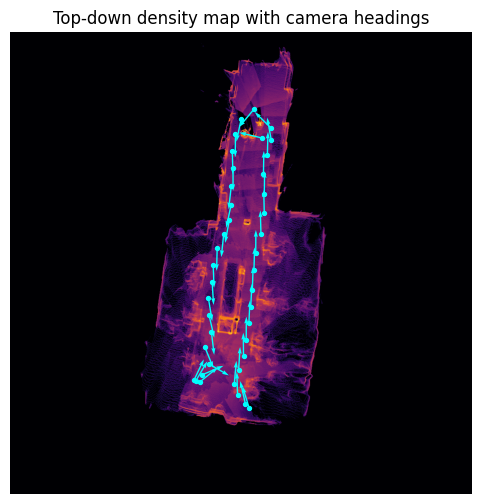

In [45]:
from vggt.utils.geometry import closed_form_inverse_se3

# Confidence-filtered points (match demo_viser percentile filtering)
conf_flat = depth_conf[0].detach().cpu().numpy().reshape(-1)
points_flat = point_map_by_unprojection.reshape(-1, 3)

percentile = 25.0
cutoff = np.percentile(conf_flat, percentile)
valid_mask = (conf_flat >= cutoff) & (conf_flat > 1e-5)
points_valid = points_flat[valid_mask]
print(f"Using {points_valid.shape[0]} high-confidence points for top-down density map")

# Estimate floor normal from camera extrinsics (OpenCV convention: +Y points down)
R_world_to_cam = extrinsic.squeeze(0).detach().cpu().numpy()[:, :3, :3]

down_dirs = R_world_to_cam[:, 1, :].copy()
ref_down = down_dirs[0]
for i in range(len(down_dirs)):
    if np.dot(down_dirs[i], ref_down) < 0:
        down_dirs[i] *= -1
avg_down = down_dirs.mean(axis=0)
floor_normal = -avg_down / np.linalg.norm(avg_down)
print(f"Estimated floor normal (world frame): {floor_normal}")

# Build horizontal basis vectors
x_dirs = R_world_to_cam[:, 0, :].copy()
for i in range(len(x_dirs)):
    if np.dot(x_dirs[i], x_dirs[0]) < 0:
        x_dirs[i] *= -1
x_dirs_proj = x_dirs - (x_dirs @ floor_normal)[:, None] * floor_normal
basis_x = x_dirs_proj.mean(axis=0)
basis_x /= np.linalg.norm(basis_x)

basis_y = np.cross(floor_normal, basis_x)
basis_y /= np.linalg.norm(basis_y)

basis = np.stack([basis_x, basis_y, floor_normal], axis=0)

# Project points into the floor-aligned frame
scene_center = points_valid.mean(axis=0)
coords = (points_valid - scene_center) @ basis.T
coords_xy = coords[:, :2]

# Normalise to a square canvas and accumulate density
extent = np.abs(coords_xy).max()
if extent < 1e-6:
    raise RuntimeError("Degenerate extent for top-down projection")
margin = 1.05
coords_norm = coords_xy / (extent * margin)

resolution = 1024
uv = ((coords_norm + 1.0) * 0.5 * (resolution - 1)).astype(int)
uv = np.clip(uv, 0, resolution - 1)
rows, cols = uv[:, 1], uv[:, 0]

density = np.zeros((resolution, resolution), dtype=np.int32)
np.add.at(density, (rows, cols), 1)

density_vis = np.log1p(density)

# Camera positions and headings in floor frame
extrinsic_batch = extrinsic.squeeze(0).detach()
S = extrinsic_batch.shape[0]
extrinsic_h = torch.zeros((S, 4, 4), dtype=extrinsic_batch.dtype, device=extrinsic_batch.device)
extrinsic_h[:, :3, :4] = extrinsic_batch
extrinsic_h[:, 3, 3] = 1.0
cam_to_world = closed_form_inverse_se3(extrinsic_h).cpu().numpy()

cam_positions = cam_to_world[:, :3, 3]
cam_coords = (cam_positions - scene_center) @ basis.T
cam_norm = cam_coords[:, :2] / (extent * margin)
cam_pix = (cam_norm + 1.0) * 0.5 * (resolution - 1)

forward_vectors = cam_to_world[:, :3, 2]
forward_coords = forward_vectors @ basis.T
forward_xy = forward_coords[:, :2]
forward_norm = np.linalg.norm(forward_xy, axis=1, keepdims=True)
forward_norm[forward_norm < 1e-6] = 1.0
forward_xy_unit = forward_xy / forward_norm
arrow_len = resolution * 0.05
arrow_vec = forward_xy_unit * arrow_len

plt.figure(figsize=(6, 6))
plt.imshow(density_vis, cmap='inferno', origin='lower')
plt.scatter(cam_pix[:, 0], cam_pix[:, 1], c='cyan', s=8, label='Camera centers')
plt.quiver(
    cam_pix[:, 0],
    cam_pix[:, 1],
    arrow_vec[:, 0],
    arrow_vec[:, 1],
    angles='xy',
    scale_units='xy',
    scale=1.0,
    color='cyan',
    width=0.003,
)
plt.title('Top-down density map with camera headings')
plt.axis('off')


## 9. Package outputs for downstream use
Wrap the tensors in a dictionary similar to the demo for reuse.

In [ ]:
predictions = {
    "images": batched_images.squeeze(0).detach().cpu(),
    "pose_enc": pose_enc.detach().cpu(),
    "extrinsic": extrinsic.detach().cpu(),
    "intrinsic": intrinsic.detach().cpu(),
    "depth": depth_map.detach().cpu(),
    "depth_conf": depth_conf.detach().cpu(),
    "world_points": point_map.detach().cpu(),
    "world_points_conf": point_conf.detach().cpu(),
    "track": track_list[-1].detach().cpu(),
    "vis": vis_score.detach().cpu(),
    "conf": conf_score.detach().cpu(),
    "world_points_from_depth": point_map_by_unprojection,
}

for key, value in predictions.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.shape} ({value.dtype})")
    else:
        print(f"{key}: numpy array with shape {value.shape} and dtype {value.dtype}")


images: torch.Size([41, 3, 294, 518]) (torch.float32)
pose_enc: torch.Size([1, 41, 9]) (torch.float32)
extrinsic: torch.Size([1, 41, 3, 4]) (torch.float32)
intrinsic: torch.Size([1, 41, 3, 3]) (torch.float32)
depth: torch.Size([1, 41, 294, 518, 1]) (torch.float32)
depth_conf: torch.Size([1, 41, 294, 518]) (torch.float32)
world_points: torch.Size([1, 41, 294, 518, 3]) (torch.float32)
world_points_conf: torch.Size([1, 41, 294, 518]) (torch.float32)
track: torch.Size([1, 41, 2, 2]) (torch.float32)
vis: torch.Size([1, 41, 2]) (torch.float32)
conf: torch.Size([1, 41, 2]) (torch.float32)
world_points_from_depth: numpy array with shape (41, 294, 518, 3) and dtype float64


## 10. Output tensor glossary
The table below summarises each tensor returned in `predictions`, its shape convention (batch `B`, frames `S`, height `H`, width `W`, tracked points `N`), and its semantic meaning:returning to earlier sections if you need more detail.

| Key | Shape | Meaning |
| --- | --- | --- |
| `images` | `(S, 3, H, W)` | Preprocessed RGB inputs in `[0, 1]`, per frame.
| `pose_enc` | `(B, S, 9)` | Camera pose encoding (translation, quaternion, FoV) for each frame.
| `extrinsic` | `(B, S, 3, 4)` | Camera-to-world 3×4 SE(3) matrices (OpenCV cam-from-world convention).
| `intrinsic` | `(B, S, 3, 3)` | Pixel intrinsics with principal point centred at `(W/2, H/2)`.
| `depth` | `(B, S, H, W, 1)` | Predicted metric depth per pixel.
| `depth_conf` | `(B, S, H, W)` | Confidence for each depth value (higher is better).
| `world_points` | `(B, S, H, W, 3)` | 3D points from the point-head branch (camera frame).
| `world_points_conf` | `(B, S, H, W)` | Confidence for each point-head prediction.
| `track` | `(B, S, N, 2)` | 2D pixel locations of user-specified tracked points across frames.
| `vis` | `(B, S, N)` | Visibility scores for the tracked points.
| `conf` | `(B, S, N)` | Confidence scores for the tracked point trajectories.
| `world_points_from_depth` | `(S, H, W, 3)` | Depth-unprojected 3D points (NumPy) in world coordinates.
